# 0. Setup

In [3]:
import uproot, awkward as ak, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
 
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("device:", device)

device: mps


# 1. Configuration

In [4]:
# ── Data ──────────────────────────────────────────────────────────────────────
input_files = {
    "at_1_bt_0": "Delphes_Data/at_1_bt_0/tag_1_delphes_events.root",
    "at_0_bt_1": "Delphes_Data/at_0_bt_1/tag_1_delphes_events.root",
    "at_1_bt_1": "Delphes_Data/at_1_bt_1/tag_1_delphes_events.root",
}
TREE_NAME           = "Delphes"
MAX_JETS            = 12
RANDOM_SEED         = 42
REQUIRE_2_PHOTONS   = True
REQUIRE_2_RECO_JETS = True
USE_MASS_WINDOW     = True
MASS_WINDOW         = 15.0      # GeV around Higgs mass
DEBUG               = False
MAX_DEBUG_EVENTS    = 50000
 
# ── Target layout ─────────────────────────────────────────────────────────────
# Each object: (log1p_pt, eta, sin(phi), cos(phi)) — 4 features
# j2 phi slot encodes Δφ_jj = delta_phi(j1, j2) as (sin(Δφ_jj), cos(Δφ_jj))
TARGET_MODE    = "Hjj"
ORDERING       = "pt_ordered"
N_FEATURES     = 4
TRUTH_OBJECTS  = ["H", "j1", "j2"]
BLOCK_SLICES   = {
    name: slice(i * N_FEATURES, (i + 1) * N_FEATURES)
    for i, name in enumerate(TRUTH_OBJECTS)
}
# y_dim = 12
 
# ── Reco input layout ─────────────────────────────────────────────────────────
N_RECO_FEATURES_PER_JET = 5    # log1p_pt, eta, sinphi, cosphi, mass
N_RECO_HIGGS_FEATURES   = 5
N_RECO_SCALAR_FEATURES  = 1    # log1p(njet)
# x_dim = 5 + 1 + 12*5 = 66
 
# ── Dataset slicing (re-run from Cell 6 without reloading) ────────────────────
N_EVENTS  = None    # None = use all available events
TEST_SIZE = 0.2
 
# ── Model ─────────────────────────────────────────────────────────────────────
COUPLING_TYPE     = "rqs"   # "affine" | "rqs"
N_BLOCKS          = 24
# affine only
AFFINE_CLAMP      = 2.0
# rqs only
SPLINE_BINS       = 16
SPLINE_TAIL       = 6.0
# conditioning subnet (preprocesses reco input before coupling blocks)
COND_SUBNET_WIDTH = 512
COND_SUBNET_DEPTH = 3       # number of hidden layers
# coupling subnet (inside each coupling block)
SUBNET_WIDTH      = 256
 
# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 2048
EPOCHS     = 1000
PATIENCE   = 100
LR         = 3e-5
 
# ── Seeds ─────────────────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# 2. Helper functions

In [6]:
def delta_phi(phi1, phi2):
    return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi
 
def block(arr, name):
    return arr[..., BLOCK_SLICES[name]]
 
def pt_from_features(feat):
    return np.expm1(feat[..., 0])
 
def eta_from_features(feat):
    return feat[..., 1]
 
def phi_from_features(feat):
    return np.arctan2(feat[..., 2], feat[..., 3])
 
def phi_j2_from_samples(samples):
    phi_j1  = phi_from_features(block(samples, "j1"))
    dphi_jj = phi_from_features(block(samples, "j2"))
    return delta_phi(phi_j1, dphi_jj)
 
def dphi_jj_from_samples(samples):
    return phi_from_features(block(samples, "j2"))
 
def deta_jj_from_samples(samples):
    return (
        eta_from_features(block(samples, "j1"))
        - eta_from_features(block(samples, "j2"))
    )
 
def pt_from_reco_features(feat):
    return np.expm1(feat[..., 0])
 
def eta_from_reco_features(feat):
    return feat[..., 1]
 
def phi_from_reco_features(feat):
    return np.arctan2(feat[..., 2], feat[..., 3])
 
def mass_from_reco_features(feat):
    return feat[..., 4]
 
def jet_features_from_reco_X(X_row, jet_idx):
    start = N_RECO_HIGGS_FEATURES + N_RECO_SCALAR_FEATURES + jet_idx * N_RECO_FEATURES_PER_JET
    end   = start + N_RECO_FEATURES_PER_JET
    return X_row[start:end]
 
def higgs_features_from_reco_X(X_row):
    return X_row[0:N_RECO_HIGGS_FEATURES]
 
def to_ml_features_truth(pt, eta, phi):
    return np.stack(
        [np.log1p(pt), eta, np.sin(phi), np.cos(phi)],
        axis=-1,
    )
 
def to_ml_features_reco(pt, eta, phi, mass):
    return np.stack(
        [np.log1p(pt), eta, np.sin(phi), np.cos(phi), mass],
        axis=-1,
    )
 
def four_vector_from_pt_eta_phi(pt, eta, phi, mass=0.0):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E  = np.sqrt(px**2 + py**2 + pz**2 + mass**2)
    return np.stack([E, px, py, pz], axis=-1)
 
def photons_to_higgs(pt1, eta1, phi1, e1, pt2, eta2, phi2, e2):
    px1 = pt1 * np.cos(phi1);  py1 = pt1 * np.sin(phi1);  pz1 = pt1 * np.sinh(eta1)
    px2 = pt2 * np.cos(phi2);  py2 = pt2 * np.sin(phi2);  pz2 = pt2 * np.sinh(eta2)
    e = e1 + e2;  px = px1 + px2;  py = py1 + py2;  pz = pz1 + pz2
    pt   = np.sqrt(px**2 + py**2)
    phi  = np.arctan2(py, px)
    p    = np.sqrt(px**2 + py**2 + pz**2)
    eta  = 0.5 * np.log((p + pz + 1e-12) / (p - pz + 1e-12))
    mass = np.sqrt(np.maximum(e**2 - px**2 - py**2 - pz**2, 0.0))
    return pt, eta, phi, mass

# 3. Load one Delphes file and build paired reco/truth rows

In [7]:
branches = [
    "Particle.PID", "Particle.Status",
    "Particle.PT", "Particle.Eta", "Particle.Phi", "Particle.Mass",
    "Jet.PT", "Jet.Eta", "Jet.Phi", "Jet.Mass",
    "Photon.PT", "Photon.Eta", "Photon.Phi", "Photon.E",
]
 
def build_dataset_from_file(path, sample_name, max_jets=MAX_JETS):
    with uproot.open(path) as f:
        arr = f[TREE_NAME].arrays(branches, library="ak")
 
    pid    = arr["Particle.PID"]
    status = arr["Particle.Status"]
 
    is_higgs       = (pid == 25) & (status == 22)
    is_hard_parton = (status == 23) & ((pid == 21) | (abs(pid) <= 5))
 
    h_pt  = arr["Particle.PT"][is_higgs]
    h_eta = arr["Particle.Eta"][is_higgs]
    h_phi = arr["Particle.Phi"][is_higgs]
 
    p_pt  = arr["Particle.PT"][is_hard_parton]
    p_eta = arr["Particle.Eta"][is_hard_parton]
    p_phi = arr["Particle.Phi"][is_hard_parton]
    p_m   = arr["Particle.Mass"][is_hard_parton]
 
    n_higgs   = ak.num(h_pt)
    n_partons = ak.num(p_pt)
    n_jets    = ak.num(arr["Jet.PT"])
    n_photons = ak.num(arr["Photon.PT"])
 
    mask = (n_higgs == 1) & (n_partons == 2)
    if REQUIRE_2_PHOTONS:   mask = mask & (n_photons >= 2)
    if REQUIRE_2_RECO_JETS: mask = mask & (n_jets >= 2)
 
    pho_pt  = arr["Photon.PT"]
    pho_eta = arr["Photon.Eta"]
    pho_phi = arr["Photon.Phi"]
    pho_e   = arr["Photon.E"]
 
    hrec_pt, hrec_eta, hrec_phi, hrec_m = photons_to_higgs(
        ak.to_numpy(pho_pt[mask][:, 0]),  ak.to_numpy(pho_eta[mask][:, 0]),
        ak.to_numpy(pho_phi[mask][:, 0]), ak.to_numpy(pho_e[mask][:, 0]),
        ak.to_numpy(pho_pt[mask][:, 1]),  ak.to_numpy(pho_eta[mask][:, 1]),
        ak.to_numpy(pho_phi[mask][:, 1]), ak.to_numpy(pho_e[mask][:, 1]),
    )
 
    mass_mask_np = np.ones(len(hrec_m), dtype=bool)
    if USE_MASS_WINDOW:
        mass_mask_np = np.abs(hrec_m - 125.0) < MASS_WINDOW
 
    arr_sel   = arr[mask]
    h_pt_sel  = h_pt[mask];  h_eta_sel = h_eta[mask];  h_phi_sel = h_phi[mask]
    p_pt_sel  = p_pt[mask];  p_eta_sel = p_eta[mask]
    p_phi_sel = p_phi[mask]; p_m_sel   = p_m[mask]
 
    truth_h = to_ml_features_truth(
        ak.to_numpy(h_pt_sel[:, 0])[mass_mask_np],
        ak.to_numpy(h_eta_sel[:, 0])[mass_mask_np],
        ak.to_numpy(h_phi_sel[:, 0])[mass_mask_np],
    )
 
    p_pt_np  = ak.to_numpy(p_pt_sel)[mass_mask_np]
    p_eta_np = ak.to_numpy(p_eta_sel)[mass_mask_np]
    p_phi_np = ak.to_numpy(p_phi_sel)[mass_mask_np]
 
    swap = p_pt_np[:, 0] < p_pt_np[:, 1]
    for a in [p_pt_np, p_eta_np, p_phi_np]:
        tmp = a[swap, 0].copy()
        a[swap, 0] = a[swap, 1]
        a[swap, 1] = tmp
 
    truth_p1 = to_ml_features_truth(p_pt_np[:, 0], p_eta_np[:, 0], p_phi_np[:, 0])
    dphi_jj  = delta_phi(p_phi_np[:, 0], p_phi_np[:, 1])
    truth_p2 = to_ml_features_truth(p_pt_np[:, 1], p_eta_np[:, 1], dphi_jj)
 
    y_truth = np.concatenate([truth_h, truth_p1, truth_p2], axis=1)  # (N, 12)
 
    hrec_feat = to_ml_features_reco(
        hrec_pt[mass_mask_np], hrec_eta[mass_mask_np],
        hrec_phi[mass_mask_np], hrec_m[mass_mask_np],
    )
 
    jet_pt  = arr_sel["Jet.PT"][mass_mask_np]
    jet_eta = arr_sel["Jet.Eta"][mass_mask_np]
    jet_phi = arr_sel["Jet.Phi"][mass_mask_np]
    jet_m   = arr_sel["Jet.Mass"][mass_mask_np]
 
    n_events  = len(y_truth)
    reco_jets = np.zeros((n_events, max_jets, N_RECO_FEATURES_PER_JET), dtype=np.float32)
 
    for j in range(max_jets):
        has_j = ak.num(jet_pt) > j
        idx   = np.where(ak.to_numpy(has_j))[0]
        if len(idx) == 0:
            continue
        reco_jets[idx, j, :] = to_ml_features_reco(
            ak.to_numpy(jet_pt[has_j][:, j]),  ak.to_numpy(jet_eta[has_j][:, j]),
            ak.to_numpy(jet_phi[has_j][:, j]), ak.to_numpy(jet_m[has_j][:, j]),
        )
 
    njets_np   = ak.to_numpy(ak.num(jet_pt)).astype(np.float32)
    njets_feat = np.log1p(njets_np).reshape(-1, 1)
 
    x_reco = np.concatenate([
        hrec_feat,
        njets_feat,
        reco_jets.reshape(n_events, max_jets * N_RECO_FEATURES_PER_JET),
    ], axis=1)  # (N, 66)
 
    meta = pd.DataFrame({
        "sample":          sample_name,
        "n_reco_jets":     njets_np,
        "reco_higgs_mass": hrec_m[mass_mask_np],
    })
 
    return x_reco.astype(np.float32), y_truth.astype(np.float32), meta

# 4. Build combined dataset from all at/bt configurations

In [8]:
# Re-running this cell is the only time you pay the I/O cost.
# After this, X_full / y_full / meta_full live in RAM.
 
X_list, y_list, meta_list = [], [], []
 
for name, path in input_files.items():
    X_i, y_i, meta_i = build_dataset_from_file(path, name)
    print(f"{name} — X: {X_i.shape}, y: {y_i.shape}")
    X_list.append(X_i)
    y_list.append(y_i)
    meta_list.append(meta_i)
 
X_full    = np.concatenate(X_list, axis=0)
y_full    = np.concatenate(y_list, axis=0)
meta_full = pd.concat(meta_list, axis=0).reset_index(drop=True)
 
assert y_full.shape[1] == len(TRUTH_OBJECTS) * N_FEATURES, \
    f"y_dim mismatch: got {y_full.shape[1]}, expected {len(TRUTH_OBJECTS) * N_FEATURES}"
 
print(f"\nFull dataset — X: {X_full.shape}, y: {y_full.shape}")
print(f"Total events: {len(X_full):,}")
print("\nSample counts:")
print(meta_full["sample"].value_counts())

at_1_bt_0 — X: (88020, 66), y: (88020, 12)
at_0_bt_1 — X: (87895, 66), y: (87895, 12)
at_1_bt_1 — X: (88178, 66), y: (88178, 12)

Full dataset — X: (264093, 66), y: (264093, 12)
Total events: 264,093

Sample counts:
sample
at_1_bt_1    88178
at_1_bt_0    88020
at_0_bt_1    87895
Name: count, dtype: int64


# 5. Shuffle reco/truth together

In [9]:
# Re-running this changes the shuffle but NOT the data loaded.
# Only re-run if you want a fresh shuffle.
 
perm   = np.random.permutation(len(X_full))
X_full = X_full[perm]
y_full = y_full[perm]
meta_full = meta_full.iloc[perm].reset_index(drop=True)
 
if DEBUG:
    print(f"DEBUG MODE: keeping first {MAX_DEBUG_EVENTS} events")
    X_full    = X_full[:MAX_DEBUG_EVENTS]
    y_full    = y_full[:MAX_DEBUG_EVENTS]
    meta_full = meta_full.iloc[:MAX_DEBUG_EVENTS].reset_index(drop=True)
 
print(f"Shuffled dataset — X: {X_full.shape}, y: {y_full.shape}")

Shuffled dataset — X: (264093, 66), y: (264093, 12)


# 6. Train/validation split and scaling

In [10]:
# Re-run this freely to change N_EVENTS, TEST_SIZE, or scaling.
# Does NOT require reloading from disk.
 
# ── Slice ─────────────────────────────────────────────────────────────────────
N = len(X_full) if N_EVENTS is None else min(N_EVENTS, len(X_full))
X = X_full[:N]
y = y_full[:N]
meta = meta_full.iloc[:N].reset_index(drop=True)
 
print(f"Using {N:,} events ({N/len(X_full)*100:.1f}% of full dataset)")
 
# ── Train / val split ─────────────────────────────────────────────────────────
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X, y, meta,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)
 
# ── Reco scaling ──────────────────────────────────────────────────────────────
# Fit on Higgs + njet + first 2 jet slots only.
# Reuse jet-1 statistics for all jet slots to avoid ±400 values in
# zero-padded high-index slots.
 
N_HIGGS_AND_NJET = N_RECO_HIGGS_FEATURES + N_RECO_SCALAR_FEATURES   # 6
fit_cols = list(range(N_HIGGS_AND_NJET + 2 * N_RECO_FEATURES_PER_JET))
 
x_scaler = StandardScaler()
x_scaler.fit(X_train[:, fit_cols])
 
x_mean  = np.zeros(X_train.shape[1], dtype=np.float32)
x_scale = np.ones(X_train.shape[1],  dtype=np.float32)
 
x_mean[:N_HIGGS_AND_NJET]  = x_scaler.mean_[:N_HIGGS_AND_NJET]
x_scale[:N_HIGGS_AND_NJET] = x_scaler.scale_[:N_HIGGS_AND_NJET]
 
jet1_mean  = x_scaler.mean_[N_HIGGS_AND_NJET : N_HIGGS_AND_NJET + N_RECO_FEATURES_PER_JET]
jet1_scale = x_scaler.scale_[N_HIGGS_AND_NJET : N_HIGGS_AND_NJET + N_RECO_FEATURES_PER_JET]
 
for j in range(MAX_JETS):
    s = N_HIGGS_AND_NJET + j * N_RECO_FEATURES_PER_JET
    x_mean[s:s + N_RECO_FEATURES_PER_JET]  = jet1_mean
    x_scale[s:s + N_RECO_FEATURES_PER_JET] = jet1_scale
 
X_train_s = ((X_train - x_mean) / x_scale).astype(np.float32)
X_val_s   = ((X_val   - x_mean) / x_scale).astype(np.float32)
 
print(f"X_train_s min/max: {X_train_s.min():.2f} / {X_train_s.max():.2f}")
 
# ── Truth scaling ─────────────────────────────────────────────────────────────
y_scaler  = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train).astype(np.float32)
y_val_s   = y_scaler.transform(y_val).astype(np.float32)
 
print(f"y_train_s min/max: {y_train_s.min():.2f} / {y_train_s.max():.2f}")
 
# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TensorDataset(torch.tensor(y_train_s), torch.tensor(X_train_s))
val_ds   = TensorDataset(torch.tensor(y_val_s),   torch.tensor(X_val_s))
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
 
x_dim = X_train_s.shape[1]   # 66
y_dim = y_train_s.shape[1]   # 12
 
print(f"\nReco dim  (x_dim):  {x_dim}")
print(f"Truth dim (y_dim):  {y_dim}")
print(f"Train events: {len(X_train):,}  |  Val events: {len(X_val):,}")
 
# Torch versions of scaler params (kept for physics penalty / future use)
y_mean_t  = torch.tensor(y_scaler.mean_,  dtype=torch.float32, device=device)
y_scale_t = torch.tensor(y_scaler.scale_, dtype=torch.float32, device=device)

Using 264,093 events (100.0% of full dataset)
X_train_s min/max: -11.81 / 22.96
y_train_s min/max: -5.55 / 5.82

Reco dim  (x_dim):  66
Truth dim (y_dim):  12
Train events: 211,274  |  Val events: 52,819


# 7. Build cINN / conditional flow with FrEIA

In [11]:
# ── Conditioning subnet ───────────────────────────────────────────────────────

class ConditioningSubnet(nn.Module):
    """
    MLP that preprocesses the reco conditioning vector.
    Input:  (batch, context_dim)   e.g. 66
    Output: (batch, COND_SUBNET_WIDTH)
    """
    def __init__(self, context_dim, width=COND_SUBNET_WIDTH, depth=COND_SUBNET_DEPTH):
        super().__init__() 
        layers = []
        in_dim = context_dim
        for _ in range(depth):
            layers += [nn.Linear(in_dim, width), nn.GELU()]
            in_dim  = width
        self.net = nn.Sequential(*layers)
        self.out_dim = width

    def forward(self, x):
        return self.net(x)


# ── Coupling subnet ───────────────────────────────────────────────────────────

def make_subnet(in_dim, out_dim, width=SUBNET_WIDTH):
    return nn.Sequential(
        nn.Linear(in_dim, width),
        nn.GELU(),
        nn.Dropout(p=0.1),
        nn.Linear(width, width),
        nn.GELU(),
        nn.Dropout(p=0.1),
        nn.Linear(width, out_dim),
    )


# ── Affine coupling block ─────────────────────────────────────────────────────

class AffineCouplingBlock(nn.Module):
    def __init__(self, x_dim, context_dim, clamp=AFFINE_CLAMP, width=SUBNET_WIDTH):
        super().__init__()
        self.x1_dim = x_dim // 2
        self.x2_dim = x_dim - self.x1_dim
        self.clamp  = clamp
        self.subnet = make_subnet(self.x1_dim + context_dim, self.x2_dim * 2, width=width)

    def _st(self, x1, context):
        h    = self.subnet(torch.cat([x1, context], dim=-1))
        s, t = h.chunk(2, dim=-1)
        s    = self.clamp * torch.tanh(s / self.clamp)
        return s, t

    def forward(self, x, context):
        x1, x2  = x[:, :self.x1_dim], x[:, self.x1_dim:]
        s, t    = self._st(x1, context)
        z2      = x2 * torch.exp(s) + t
        log_det = s.sum(dim=-1)
        return torch.cat([x1, z2], dim=-1), log_det

    def inverse(self, z, context):
        z1, z2 = z[:, :self.x1_dim], z[:, self.x1_dim:]
        s, t   = self._st(z1, context)
        x2     = (z2 - t) * torch.exp(-s)
        return torch.cat([z1, x2], dim=-1)


# ── Rational Quadratic Spline ─────────────────────────────────────────────────
# Durkan et al. 2019 — Neural Spline Flows, NeurIPS

def _rqs_forward_batched(x, widths, heights, derivatives, tail):
    """
    Vectorised RQS forward pass.
    x:           (batch, D)
    widths:      (batch, D, K)
    heights:     (batch, D, K)
    derivatives: (batch, D, K+1)
    returns:     z (batch, D), log_det (batch, D)
    """
    cum_w = F.pad(torch.cumsum(widths,  dim=-1), (1, 0), value=0.0) - tail
    cum_h = F.pad(torch.cumsum(heights, dim=-1), (1, 0), value=0.0) - tail

    bin_idx = (x.unsqueeze(-1) >= cum_w[..., :-1]).sum(dim=-1) - 1
    bin_idx = bin_idx.clamp(0, widths.shape[-1] - 1)

    idx  = bin_idx.unsqueeze(-1)
    w_k  = widths.gather(-1, idx).squeeze(-1)
    h_k  = heights.gather(-1, idx).squeeze(-1)
    d_k  = derivatives[..., :-1].gather(-1, idx).squeeze(-1)
    d_k1 = derivatives[..., 1:].gather(-1, idx).squeeze(-1)
    x_k  = cum_w[..., :-1].gather(-1, idx).squeeze(-1)
    y_k  = cum_h[..., :-1].gather(-1, idx).squeeze(-1)

    s_k = h_k / w_k
    xi  = ((x - x_k) / w_k).clamp(0.0, 1.0)

    num    = h_k * (s_k * xi**2 + d_k * xi * (1 - xi))
    den    = s_k + ((d_k + d_k1 - 2 * s_k) * xi * (1 - xi))
    z      = y_k + num / den

    dnum   = 2 * s_k * xi * (1 - xi) + d_k * (1 - xi)**2 + d_k1 * xi**2
    log_dz = torch.log(s_k**2 * dnum) - 2 * torch.log(den.abs() + 1e-8)

    return z, log_dz


def _rqs_inverse_batched(z, widths, heights, derivatives, tail):
    """
    Vectorised RQS inverse pass.
    z:           (batch, D)
    widths:      (batch, D, K)
    heights:     (batch, D, K)
    derivatives: (batch, D, K+1)
    returns:     x (batch, D)
    """
    cum_w = F.pad(torch.cumsum(widths,  dim=-1), (1, 0), value=0.0) - tail
    cum_h = F.pad(torch.cumsum(heights, dim=-1), (1, 0), value=0.0) - tail

    bin_idx = (z.unsqueeze(-1) >= cum_h[..., :-1]).sum(dim=-1) - 1
    bin_idx = bin_idx.clamp(0, widths.shape[-1] - 1)

    idx  = bin_idx.unsqueeze(-1)
    w_k  = widths.gather(-1, idx).squeeze(-1)
    h_k  = heights.gather(-1, idx).squeeze(-1)
    d_k  = derivatives[..., :-1].gather(-1, idx).squeeze(-1)
    d_k1 = derivatives[..., 1:].gather(-1, idx).squeeze(-1)
    x_k  = cum_w[..., :-1].gather(-1, idx).squeeze(-1)
    y_k  = cum_h[..., :-1].gather(-1, idx).squeeze(-1)

    s_k  = h_k / w_k
    zeta = z - y_k

    a    =  h_k * (s_k - d_k)  + zeta * (d_k + d_k1 - 2 * s_k)
    b    =  h_k * d_k           - zeta * (d_k + d_k1 - 2 * s_k)
    c    = -s_k * zeta

    disc = (b**2 - 4 * a * c).clamp(min=0.0)
    xi   = (2 * c / (-b - torch.sqrt(disc))).clamp(0.0, 1.0)

    return xi * w_k + x_k


# ── RQS Coupling Block ────────────────────────────────────────────────────────

class RQSCouplingBlock(nn.Module):
    def __init__(self, x_dim, context_dim, K=SPLINE_BINS, tail=SPLINE_TAIL, width=SUBNET_WIDTH):
        super().__init__()
        self.x1_dim           = x_dim // 2
        self.x2_dim           = x_dim - self.x1_dim
        self.K                = K
        self.tail             = tail
        self.n_params_per_dim = 3 * K + 1
        self.subnet = make_subnet(
            self.x1_dim + context_dim,
            self.x2_dim * self.n_params_per_dim,
            width=width,
        )

    def _params(self, x1, context):
        raw = self.subnet(torch.cat([x1, context], dim=-1))
        raw = raw.view(*raw.shape[:-1], self.x2_dim, self.n_params_per_dim)
        W   = raw[..., :self.K]
        H   = raw[..., self.K : 2 * self.K]
        D   = raw[..., 2 * self.K:]
        return (
            F.softmax(W, dim=-1) * 2 * self.tail,
            F.softmax(H, dim=-1) * 2 * self.tail,
            F.softplus(D),
        )

    def forward(self, x, context):
        x1, x2 = x[:, :self.x1_dim], x[:, self.x1_dim:]
        widths, heights, derivatives = self._params(x1, context)

        inside        = ((x2 >= -self.tail) & (x2 <= self.tail)).float()
        z2_in, ld_in  = _rqs_forward_batched(x2, widths, heights, derivatives, self.tail)
        z2      = inside * z2_in + (1.0 - inside) * x2
        log_det = (inside * ld_in).sum(dim=-1)

        return torch.cat([x1, z2], dim=-1), log_det

    def inverse(self, z, context):
        z1, z2 = z[:, :self.x1_dim], z[:, self.x1_dim:]
        widths, heights, derivatives = self._params(z1, context)

        inside = ((z2 >= -self.tail) & (z2 <= self.tail)).float()
        x2_in  = _rqs_inverse_batched(z2, widths, heights, derivatives, self.tail)
        x2     = inside * x2_in + (1.0 - inside) * z2

        return torch.cat([z1, x2], dim=-1)


# ── Fixed random permutation ──────────────────────────────────────────────────

class Permutation(nn.Module):
    def __init__(self, dim, seed):
        super().__init__()
        rng  = np.random.RandomState(seed)
        perm = rng.permutation(dim).astype(np.int64)
        inv  = np.argsort(perm).astype(np.int64)
        self.register_buffer("perm", torch.tensor(perm))
        self.register_buffer("inv",  torch.tensor(inv))

    def forward(self, x):
        return x[:, self.perm]

    def inverse(self, x):
        return x[:, self.inv]


# ── cINN ──────────────────────────────────────────────────────────────────────

COUPLING_REGISTRY = {
    "affine": AffineCouplingBlock,
    "rqs":    RQSCouplingBlock,
}

class cINN(nn.Module):
    def __init__(
        self,
        target_dim,
        context_dim,
        n_blocks     = N_BLOCKS,
        coupling     = COUPLING_TYPE,
        cond_width   = COND_SUBNET_WIDTH,
        cond_depth   = COND_SUBNET_DEPTH,
        subnet_width = SUBNET_WIDTH,
    ):
        super().__init__()

        if coupling not in COUPLING_REGISTRY:
            raise ValueError(
                f"Unknown coupling type '{coupling}'. "
                f"Available: {list(COUPLING_REGISTRY.keys())}"
            )

        self.cond_net = ConditioningSubnet(context_dim, width=cond_width, depth=cond_depth)
        c_dim         = self.cond_net.out_dim

        CouplingClass = COUPLING_REGISTRY[coupling]
        self.blocks   = nn.ModuleList()
        self.perms    = nn.ModuleList()

        for k in range(n_blocks):
            self.blocks.append(CouplingClass(target_dim, c_dim, width=subnet_width))
            self.perms.append(Permutation(target_dim, seed=k))

    def forward(self, x, context):
        c       = self.cond_net(context)
        log_det = torch.zeros(x.shape[0], device=x.device)

        for block, perm in zip(self.blocks, self.perms):
            x, ld = block(x, c)
            log_det += ld
            x = perm(x)

        return x, log_det

    def inverse(self, z, context):
        c = self.cond_net(context)

        for block, perm in zip(reversed(self.blocks), reversed(self.perms)):
            z = perm.inverse(z)
            z = block.inverse(z, c)

        return z


# ── Instantiate ───────────────────────────────────────────────────────────────
model = cINN(
    target_dim   = y_dim,
    context_dim  = x_dim,
    n_blocks     = N_BLOCKS,
    coupling     = COUPLING_TYPE,
    cond_width   = COND_SUBNET_WIDTH,
    cond_depth   = COND_SUBNET_DEPTH,
    subnet_width = SUBNET_WIDTH,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"Coupling type:        {COUPLING_TYPE}")
print(f"N blocks:             {N_BLOCKS}")
print(f"Target dim (y_dim):   {y_dim}")
print(f"Context dim (x_dim):  {x_dim}")
print(f"Cond subnet:          {COND_SUBNET_DEPTH}x{COND_SUBNET_WIDTH}")
print(f"Coupling subnet:      2x{SUBNET_WIDTH}")

Trainable parameters: 7,140,752
Coupling type:        rqs
N blocks:             24
Target dim (y_dim):   12
Context dim (x_dim):  66
Cond subnet:          3x512
Coupling subnet:      2x256


# 8. Negative log-likelihood + physics penalty

In [12]:
def cinn_nll(model, x_truth, x_reco):
    """
    Gaussian NLL for a normalising flow:
        L = 0.5 * ||z||² - log|det J|
    """
    z, log_det = model(x_truth, x_reco)
    return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det)
 

# 9. Training loop with checkpointing + scheduler

In [25]:
# =============================================================================
# CELL 9 — Training loop
# =============================================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = "min",
    patience = 30,       # increased from 20
    factor   = 0.5,
    min_lr   = 1e-5,     # prevent lr dying too early
)

train_losses      = []
train_eval_losses = []  # train NLL with dropout off
val_losses        = []
best_val          = float("inf")
patience_counter  = 0

run_timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
best_ckpt_path = (
    f"best_cinn_{run_timestamp}_"
    f"{TARGET_MODE}_{ORDERING}_"
    f"maxjets{MAX_JETS}_blocks{N_BLOCKS}_"
    f"lr{LR}_{COUPLING_TYPE}.pt"
)

MODEL_CONFIG = dict(
    target_dim   = y_dim,
    context_dim  = x_dim,
    n_blocks     = N_BLOCKS,
    coupling     = COUPLING_TYPE,
    cond_width   = COND_SUBNET_WIDTH,
    cond_depth   = COND_SUBNET_DEPTH,
    subnet_width = SUBNET_WIDTH,
    spline_bins  = SPLINE_BINS,
    spline_tail  = SPLINE_TAIL,
    affine_clamp = AFFINE_CLAMP,
    target_mode  = TARGET_MODE,
    ordering     = ORDERING,
    max_jets     = MAX_JETS,
    n_features   = N_FEATURES,
)

for epoch in range(EPOCHS):

    # ── Training (dropout on) ─────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for yb, xb in train_loader:
        yb = yb.to(device)
        xb = xb.to(device)
        optimizer.zero_grad()
        loss = cinn_nll(model, yb, xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(yb)

    train_loss = running_loss / len(train_loader.dataset)

    # ── Validation (dropout off) ──────────────────────────────────────────
    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for yb, xb in val_loader:
            yb = yb.to(device)
            xb = xb.to(device)
            running_val += cinn_nll(model, yb, xb).item() * len(yb)

    val_loss = running_val / len(val_loader.dataset)

    # ── Train eval (dropout off) ──────────────────────────────────────────
    running_train_eval = 0.0

    with torch.no_grad():
        for yb, xb in train_loader:
            yb = yb.to(device)
            xb = xb.to(device)
            running_train_eval += cinn_nll(model, yb, xb).item() * len(yb)

    train_eval_loss = running_train_eval / len(train_loader.dataset)

    train_losses.append(train_loss)
    train_eval_losses.append(train_eval_loss)
    val_losses.append(val_loss)

    # ── Scheduler step ────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ── Checkpoint + early stopping ───────────────────────────────────────
    if val_loss < best_val:
        best_val         = val_loss
        patience_counter = 0
        torch.save({
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch":                epoch,
            "val_loss":             val_loss,
            "model_config":         MODEL_CONFIG,
        }, best_ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"epoch {epoch+1:03d} | "
        f"train {train_loss:.4f} | "
        f"train_eval {train_eval_loss:.4f} | "
        f"val {val_loss:.4f} | "
        f"lr {current_lr:.2e} | "
        f"best {best_val:.4f}"
    )

print(f"\nBest checkpoint: {best_ckpt_path}")

epoch 001 | train 4.9112 | train_eval 0.8481 | val 0.8553 | lr 3.00e-05 | best 0.8553
epoch 002 | train -0.4302 | train_eval -2.7584 | val -2.7450 | lr 3.00e-05 | best -2.7450
epoch 003 | train -3.2330 | train_eval -4.6888 | val -4.6603 | lr 3.00e-05 | best -4.6603
epoch 004 | train -4.1406 | train_eval -5.1020 | val -5.0705 | lr 3.00e-05 | best -5.0705
epoch 005 | train -4.6499 | train_eval -5.6820 | val -5.6412 | lr 3.00e-05 | best -5.6412
epoch 006 | train -5.1394 | train_eval -6.1668 | val -6.1247 | lr 3.00e-05 | best -6.1247
epoch 007 | train -5.5324 | train_eval -6.3971 | val -6.3508 | lr 3.00e-05 | best -6.3508
epoch 008 | train -5.9039 | train_eval -6.9235 | val -6.8753 | lr 3.00e-05 | best -6.8753
epoch 009 | train -6.1991 | train_eval -7.1228 | val -7.0668 | lr 3.00e-05 | best -7.0668
epoch 010 | train -6.4276 | train_eval -7.2869 | val -7.2269 | lr 3.00e-05 | best -7.2269
epoch 011 | train -6.7220 | train_eval -7.7809 | val -7.7217 | lr 3.00e-05 | best -7.7217
epoch 012 | tr

# 10. Training curves

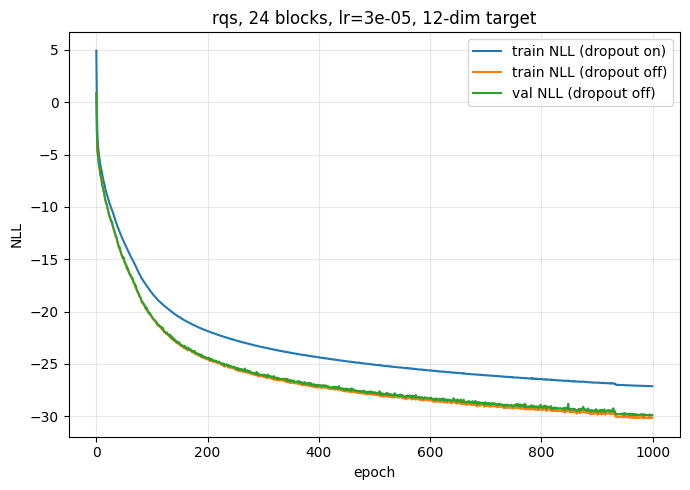

Final train NLL (dropout on)  : -27.1240
Final train NLL (dropout off) : -30.1384
Final val NLL   (dropout off) : -29.8739
Dropout gap (train off - on)  : -3.0144
Overfit gap (val - train off) : +0.2646


In [26]:
# ── Cell 10: Training curves ──────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(train_losses,      label="train NLL (dropout on)")
plt.plot(train_eval_losses, label="train NLL (dropout off)")
plt.plot(val_losses,        label="val NLL (dropout off)")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.title(
    f"{COUPLING_TYPE}, {N_BLOCKS} blocks, "
    f"lr={LR}, {y_dim}-dim target"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Quantitative summary ──────────────────────────────────────
print(f"Final train NLL (dropout on)  : {train_losses[-1]:.4f}")
print(f"Final train NLL (dropout off) : {train_eval_losses[-1]:.4f}")
print(f"Final val NLL   (dropout off) : {val_losses[-1]:.4f}")
print(f"Dropout gap (train off - on)  : {train_eval_losses[-1] - train_losses[-1]:+.4f}")
print(f"Overfit gap (val - train off) : {val_losses[-1] - train_eval_losses[-1]:+.4f}")

In [13]:
# ── Cell 11: Single-event posterior sampling ──────────────────

def sample_truth_given_reco(model, x_reco_scaled, n_samples=1000):
    """
    Generate posterior samples for a single reco event.
 
    x_reco_scaled : (context_dim,)
    returns       : (n_samples, y_dim) in unscaled truth space
    """
    model.eval()
    context = torch.tensor(x_reco_scaled[None, :], dtype=torch.float32, device=device)
    context = context.repeat(n_samples, 1)
    z       = torch.randn(n_samples, y_dim, device=device)
 
    with torch.no_grad():
        x_samples = model.inverse(z, context)
 
    return x_samples.cpu().numpy()


# ── Load best checkpoint before sampling ─────────────────────
# checkpoint = torch.load(best_ckpt_path, map_location=device)

checkpoint = torch.load("best_cinn_20260619_014456_Hjj_pt_ordered_maxjets12_blocks24_lr3e-05_rqs.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded epoch {checkpoint['epoch']+1}, val loss {checkpoint['val_loss']:.4f}")

# ── Sample for one validation event ──────────────────────────
idx            = 0
samples_scaled = sample_truth_given_reco(model, X_val_s[idx], n_samples=2000)
samples        = y_scaler.inverse_transform(samples_scaled)
truth          = y_val[idx]

print(f"samples shape: {samples.shape}")
print(f"truth shape:   {truth.shape}")
print(f"\nEvent info:")
print(f"  sample/config: {meta_val.iloc[idx]['sample']}")
print(f"  n reco jets:   {meta_val.iloc[idx]['n_reco_jets']}")
print(f"  reco H mass:   {meta_val.iloc[idx]['reco_higgs_mass']:.2f} GeV")

Loaded epoch 994, val loss -29.9269
samples shape: (2000, 12)
truth shape:   (12,)

Event info:
  sample/config: at_1_bt_0
  n reco jets:   3.0
  reco H mass:   125.42 GeV


# 12. Single-event posterior diagnostic: 
## hard truth vs detector vs flow posterior

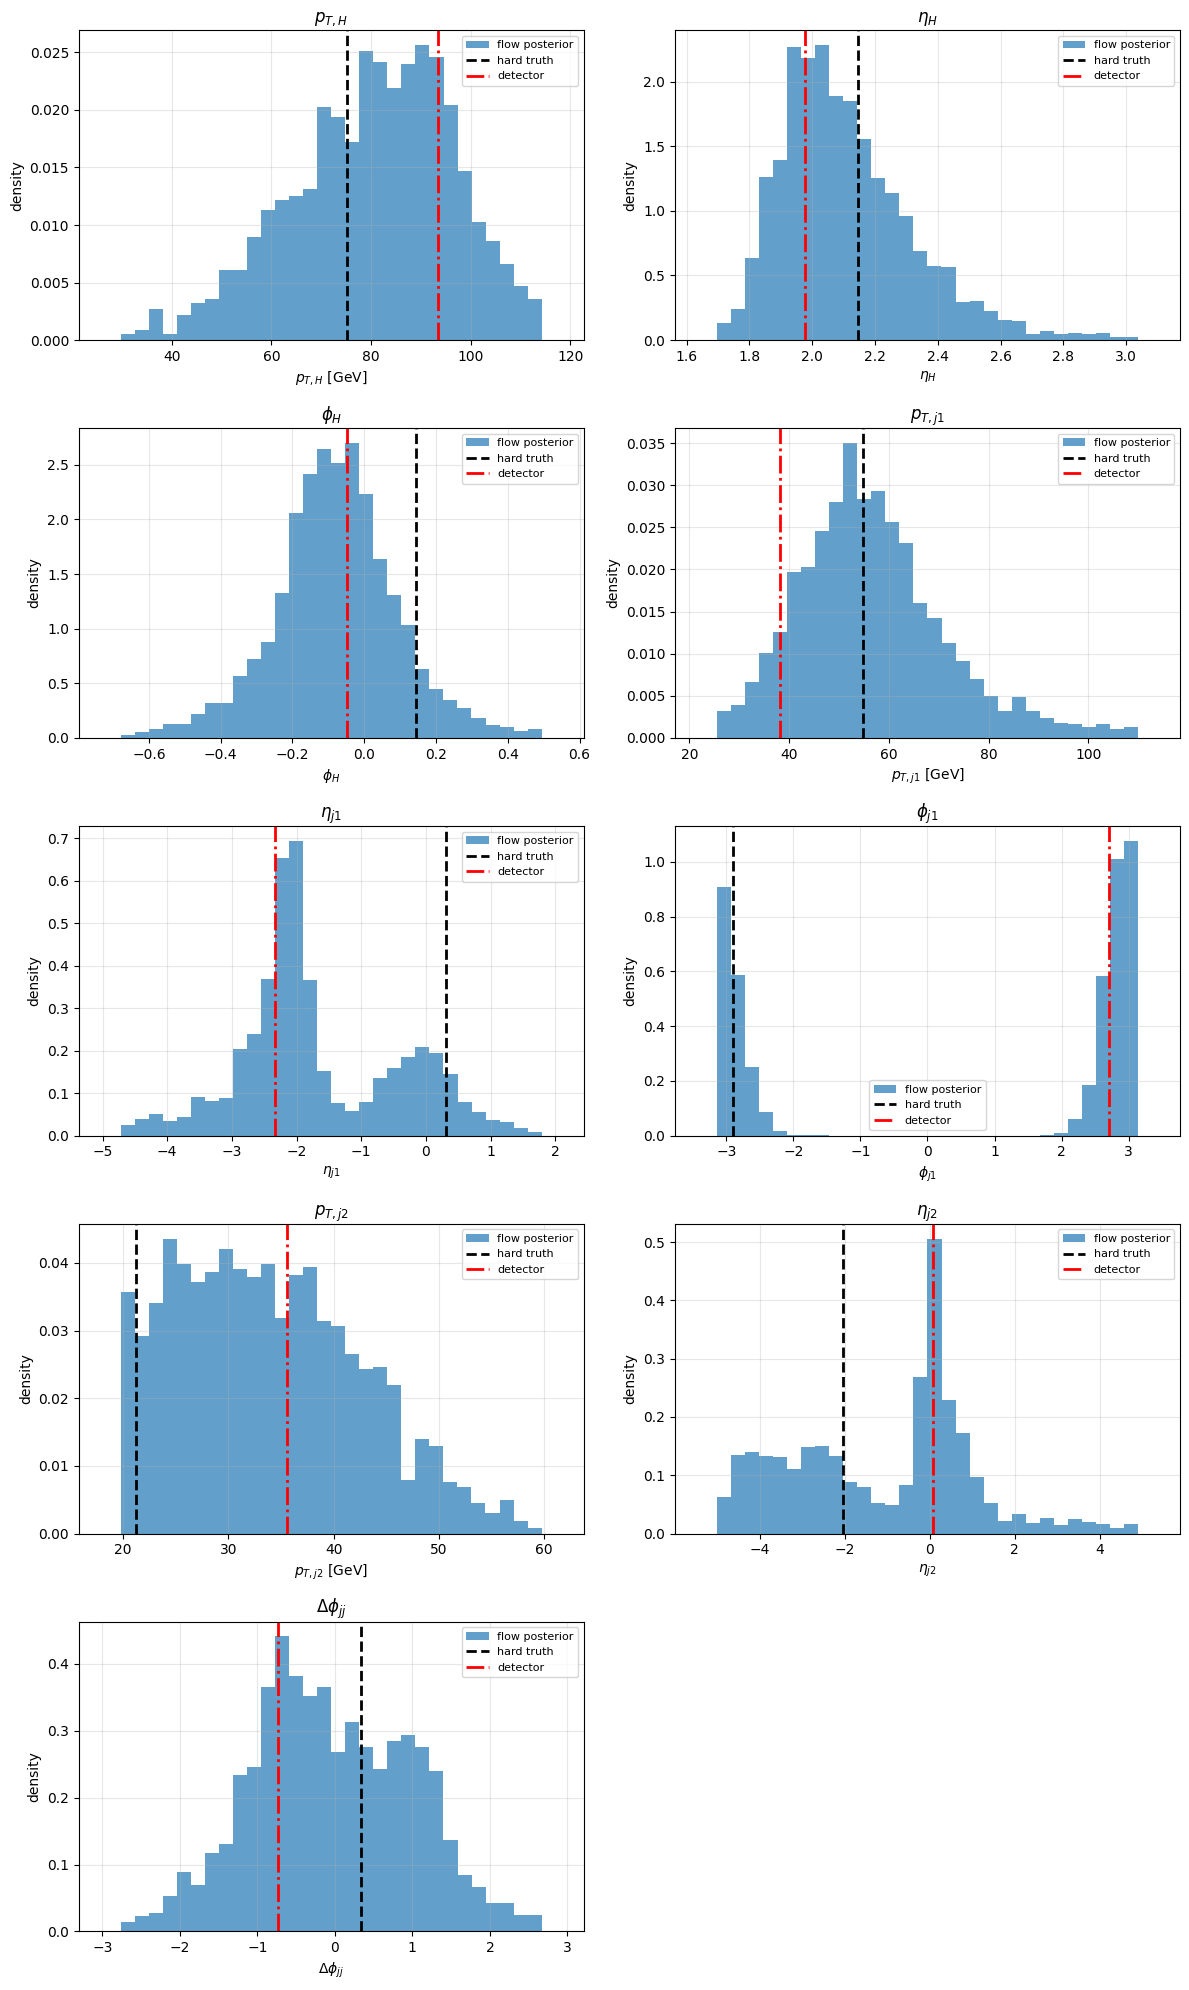

In [15]:
# ── Cell 12: Single-event posterior plots ────────────────────

# Layout: [H(3), j1(3), j2(3)] where j2 phi slot = Δφ_jj
s_H  = samples[:, BLOCK_SLICES["H"]]
s_p1 = samples[:, BLOCK_SLICES["j1"]]
s_p2 = samples[:, BLOCK_SLICES["j2"]]

t_H  = truth[BLOCK_SLICES["H"]]
t_p1 = truth[BLOCK_SLICES["j1"]]
t_p2 = truth[BLOCK_SLICES["j2"]]

rH  = higgs_features_from_reco_X(X_val[idx])
rj1 = jet_features_from_reco_X(X_val[idx], 0)
rj2 = jet_features_from_reco_X(X_val[idx], 1)

# ── Build variables dict ──────────────────────────────────────
variables = {}

# Higgs
variables[r"$p_{T,H}$"] = {
    "samples": pt_from_features(s_H),
    "truth":   pt_from_features(t_H),
    "reco":    pt_from_reco_features(rH),
    "xlabel":  r"$p_{T,H}$ [GeV]",
}
variables[r"$\eta_H$"] = {
    "samples": eta_from_features(s_H),
    "truth":   eta_from_features(t_H),
    "reco":    eta_from_reco_features(rH),
    "xlabel":  r"$\eta_H$",
}
variables[r"$\phi_H$"] = {
    "samples": phi_from_features(s_H),
    "truth":   phi_from_features(t_H),
    "reco":    phi_from_reco_features(rH),
    "xlabel":  r"$\phi_H$",
}

# j1
variables[r"$p_{T,j1}$"] = {
    "samples": pt_from_features(s_p1),
    "truth":   pt_from_features(t_p1),
    "reco":    pt_from_reco_features(rj1),
    "xlabel":  r"$p_{T,j1}$ [GeV]",
}
variables[r"$\eta_{j1}$"] = {
    "samples": eta_from_features(s_p1),
    "truth":   eta_from_features(t_p1),
    "reco":    eta_from_reco_features(rj1),
    "xlabel":  r"$\eta_{j1}$",
}
variables[r"$\phi_{j1}$"] = {
    "samples": phi_from_features(s_p1),
    "truth":   phi_from_features(t_p1),
    "reco":    phi_from_reco_features(rj1),
    "xlabel":  r"$\phi_{j1}$",
}

# j2 — phi slot is Δφ_jj
variables[r"$p_{T,j2}$"] = {
    "samples": pt_from_features(s_p2),
    "truth":   pt_from_features(t_p2),
    "reco":    pt_from_reco_features(rj2),
    "xlabel":  r"$p_{T,j2}$ [GeV]",
}
variables[r"$\eta_{j2}$"] = {
    "samples": eta_from_features(s_p2),
    "truth":   eta_from_features(t_p2),
    "reco":    eta_from_reco_features(rj2),
    "xlabel":  r"$\eta_{j2}$",
}
variables[r"$\Delta\phi_{jj}$"] = {
    "samples": phi_from_features(s_p2),   # phi slot of j2 = Δφ_jj
    "truth":   phi_from_features(t_p2),
    "reco":    delta_phi(
        phi_from_reco_features(rj1),
        phi_from_reco_features(rj2),
    ),
    "xlabel":  r"$\Delta\phi_{jj}$",
}

# ── Plot grid ─────────────────────────────────────────────────
nvars = len(variables)
ncols = 2
nrows = int(np.ceil(nvars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

for ax, (name, info) in zip(axes, variables.items()):

    vals      = np.asarray(info["samples"])
    truth_val = float(info["truth"])
    reco_val  = float(info["reco"])

    lo, hi = np.percentile(vals, [0.5, 99.5])
    vals_plot = vals[(vals >= lo) & (vals <= hi)]

    ax.hist(vals_plot, bins=30, density=True, alpha=0.7, label="flow posterior")

    xmin = min(lo, truth_val, reco_val)
    xmax = max(hi, truth_val, reco_val)
    pad  = 0.1 * (xmax - xmin + 1e-9)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.axvline(truth_val, color="black", linestyle="--", linewidth=2, label="hard truth")
    ax.axvline(reco_val,  color="red",   linestyle="-.", linewidth=2, label="detector")

    ax.set_xlabel(info["xlabel"])
    ax.set_ylabel("density")
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[nvars:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 13. Test over validation set
## Higgs + two hard partons target

In [16]:
# ── Cell 13: Ensemble closure — batched ──────────────────────────────────────

N_SAMPLES_PER_EVENT  = 100
BATCH_SIZE_INFERENCE = 512

model.eval()

flow_samples_all  = []
truth_samples_all = []

n_val = len(X_val_s)

with torch.no_grad():
    for start in range(0, n_val, BATCH_SIZE_INFERENCE):
        end    = min(start + BATCH_SIZE_INFERENCE, n_val)
        batch_n = end - start

        if start % 5000 == 0:
            print(f"processing {start}/{n_val}")

        # repeat each reco event N_SAMPLES_PER_EVENT times
        xb     = torch.tensor(X_val_s[start:end], dtype=torch.float32, device=device)
        xb_rep = xb.repeat_interleave(N_SAMPLES_PER_EVENT, dim=0)

        # draw latent samples and run inverse
        z              = torch.randn(batch_n * N_SAMPLES_PER_EVENT, y_dim, device=device)
        samples_scaled = model.inverse(z, xb_rep)
        samples        = y_scaler.inverse_transform(samples_scaled.cpu().numpy())

        flow_samples_all.append(samples)
        truth_samples_all.append(y_val[start:end])

flow_samples_all  = np.concatenate(flow_samples_all,  axis=0)
truth_samples_all = np.concatenate(truth_samples_all, axis=0)

# ── Reco observables ──────────────────────────────────────────────────────────
reco_obs = {
    "H_pt":  np.array([pt_from_reco_features(higgs_features_from_reco_X(row))  for row in X_val[:n_val]]),
    "H_eta": np.array([eta_from_reco_features(higgs_features_from_reco_X(row)) for row in X_val[:n_val]]),
    "H_phi": np.array([phi_from_reco_features(higgs_features_from_reco_X(row)) for row in X_val[:n_val]]),
    "j1_pt":  np.array([pt_from_reco_features(jet_features_from_reco_X(row, 0))  for row in X_val[:n_val]]),
    "j1_eta": np.array([eta_from_reco_features(jet_features_from_reco_X(row, 0)) for row in X_val[:n_val]]),
    "j2_pt":  np.array([pt_from_reco_features(jet_features_from_reco_X(row, 1))  for row in X_val[:n_val]]),
    "j2_eta": np.array([eta_from_reco_features(jet_features_from_reco_X(row, 1)) for row in X_val[:n_val]]),
    "dphi":   np.array([delta_phi(
                    phi_from_reco_features(jet_features_from_reco_X(row, 0)),
                    phi_from_reco_features(jet_features_from_reco_X(row, 1)),
                ) for row in X_val[:n_val]]),
    "deta":   np.array([
                    eta_from_reco_features(jet_features_from_reco_X(row, 0)) -
                    eta_from_reco_features(jet_features_from_reco_X(row, 1))
                for row in X_val[:n_val]]),
}

# ── Truth and flow observables ────────────────────────────────────────────────
def get_obs(arr):
    return {
        "H_pt":  pt_from_features(block(arr, "H")),
        "H_eta": eta_from_features(block(arr, "H")),
        "H_phi": phi_from_features(block(arr, "H")),
        "j1_pt":  pt_from_features(block(arr, "j1")),
        "j1_eta": eta_from_features(block(arr, "j1")),
        "j2_pt":  pt_from_features(block(arr, "j2")),
        "j2_eta": eta_from_features(block(arr, "j2")),
        "dphi":   phi_from_features(block(arr, "j2")),
        "deta":   eta_from_features(block(arr, "j1")) - eta_from_features(block(arr, "j2")),
    }

truth_obs = get_obs(truth_samples_all)
flow_obs  = get_obs(flow_samples_all)

print("done")
print(f"truth events: {len(truth_samples_all)}")
print(f"flow samples: {len(flow_samples_all)}")

processing 0/52819
done
truth events: 52819
flow samples: 5281900


# 14. Plots with ratios

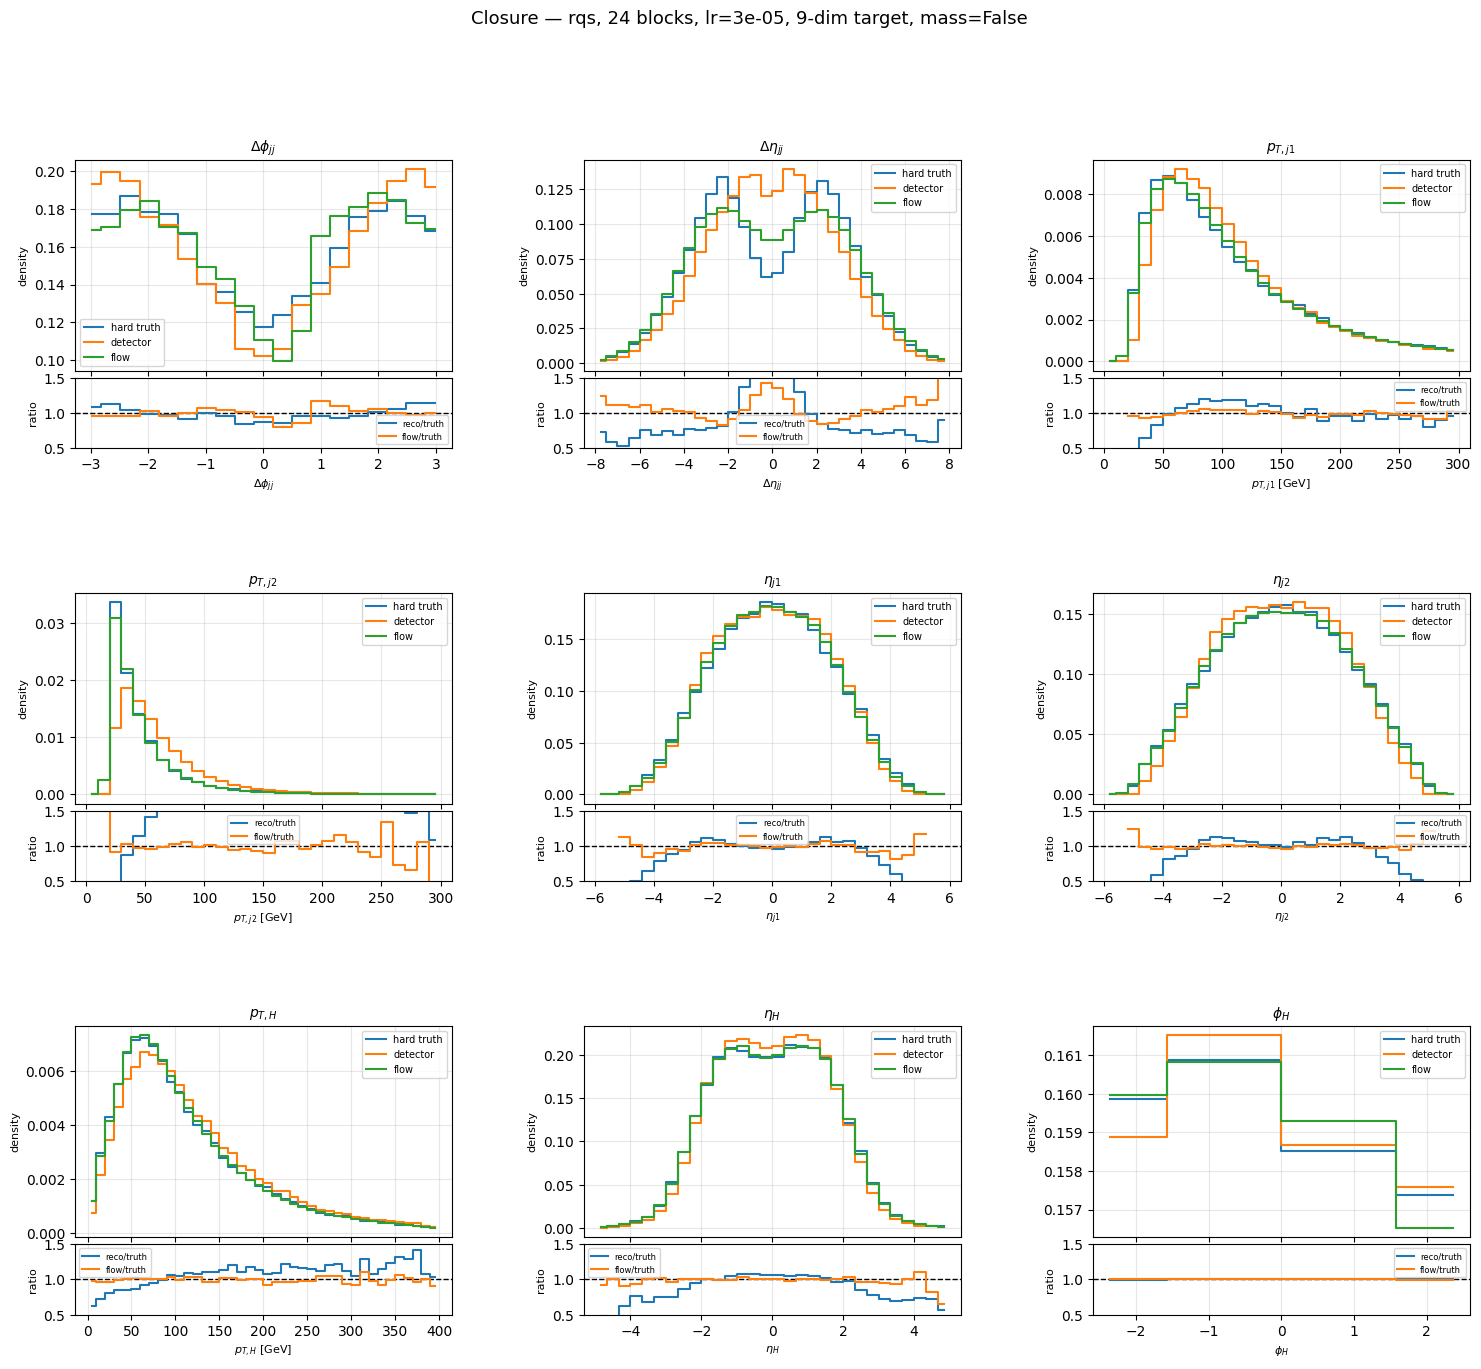

In [44]:
# ── Cell 14: Closure plots ────────────────────────────────────

def hist_density(values, bins):
    counts, edges = np.histogram(values, bins=bins, density=False)
    widths  = np.diff(edges)
    area    = np.sum(counts * widths)
    density = counts / area if area > 0 else np.zeros_like(counts, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return density, centers

def safe_ratio(num, den):
    out  = np.full_like(num, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out

plot_specs = [
    ("dphi",   np.linspace(-np.pi, np.pi, 20), r"$\Delta\phi_{jj}$",  r"$\Delta\phi_{jj}$"),
    ("deta",   np.linspace(-8, 8, 33),          r"$\Delta\eta_{jj}$",  r"$\Delta\eta_{jj}$"),
    ("j1_pt",  np.linspace(0, 300, 31),         r"$p_{T,j1}$ [GeV]",  r"$p_{T,j1}$"),
    ("j2_pt",  np.linspace(0, 300, 31),         r"$p_{T,j2}$ [GeV]",  r"$p_{T,j2}$"),
    ("j1_eta", np.linspace(-6, 6, 31),          r"$\eta_{j1}$",        r"$\eta_{j1}$"),
    ("j2_eta", np.linspace(-6, 6, 31),          r"$\eta_{j2}$",        r"$\eta_{j2}$"),
    ("H_pt",   np.linspace(0, 400, 41),         r"$p_{T,H}$ [GeV]",   r"$p_{T,H}$"),
    ("H_eta",  np.linspace(-5, 5, 31),          r"$\eta_H$",           r"$\eta_H$"),
    ("H_phi",  np.linspace(-np.pi, np.pi, 5),  r"$\phi_H$",           r"$\phi_H$"),
]

ncols  = 3
nplots = len(plot_specs)
nrows  = int(np.ceil(nplots / ncols))

fig = plt.figure(figsize=(18, 5 * nrows))
outer = fig.add_gridspec(nrows, ncols, hspace=0.5, wspace=0.35)

for i, (key, bins, xlabel, title) in enumerate(plot_specs):
    col = i % ncols
    row = i // ncols

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax    = fig.add_subplot(inner[0])
    rax   = fig.add_subplot(inner[1], sharex=ax)

    truth_h, centers = hist_density(truth_obs[key], bins)
    reco_h,  _       = hist_density(reco_obs[key],  bins)
    flow_h,  _       = hist_density(flow_obs[key],  bins)

    reco_ratio = safe_ratio(reco_h, truth_h)
    flow_ratio = safe_ratio(flow_h, truth_h)

    ax.step(centers, truth_h, where="mid", linewidth=1.5, label="hard truth")
    ax.step(centers, reco_h,  where="mid", linewidth=1.5, label="detector")
    ax.step(centers, flow_h,  where="mid", linewidth=1.5, label="flow")
    ax.set_ylabel("density", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
    ax.tick_params(labelbottom=False)

    rax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    rax.step(centers, reco_ratio, where="mid", linewidth=1.5, label="reco/truth")
    rax.step(centers, flow_ratio, where="mid", linewidth=1.5, label="flow/truth")
    rax.set_xlabel(xlabel, fontsize=8)
    rax.set_ylabel("ratio",   fontsize=8)
    rax.set_ylim(0.5, 1.5)
    rax.grid(alpha=0.3)
    rax.legend(fontsize=6)

fig.suptitle(
    f"Closure — {COUPLING_TYPE}, {N_BLOCKS} blocks, "
    f"lr={LR}, 9-dim target, mass={False}",
    fontsize=13,
)

plt.show()

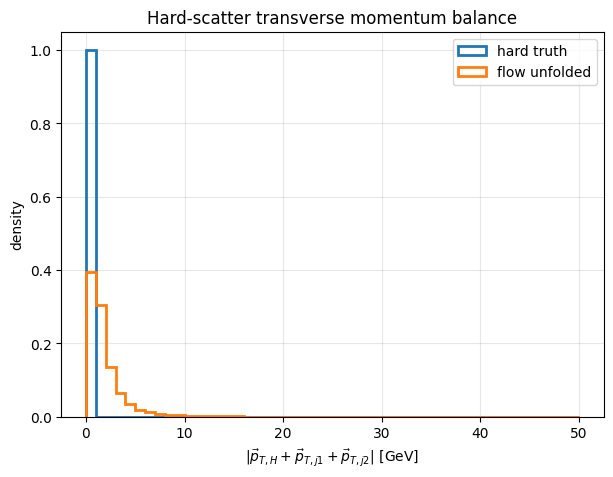

Truth pT balance — mean: 0.00, median: 0.00
Flow  pT balance — mean: 2.05,  median: 1.26
Finite fraction: 1.0000


In [18]:
# ── Cell 15: pT balance diagnostic ───────────────────────────

def px_from_features(feat):
    pt  = pt_from_features(feat)
    phi = phi_from_features(feat)
    return pt * np.cos(phi)

def py_from_features(feat):
    pt  = pt_from_features(feat)
    phi = phi_from_features(feat)
    return pt * np.sin(phi)

def pT_balance(arr):
    """
    Compute |pT_H + pT_j1 + pT_j2| for each event.
    Note: j2 phi slot = Δφ_jj, so we recover phi_j2 first.
    """
    H_feat  = block(arr, "H")
    j1_feat = block(arr, "j1")

    phi_j2  = phi_j2_from_samples(arr)
    pt_j2   = pt_from_features(block(arr, "j2"))

    px_sum = (
        px_from_features(H_feat)
        + px_from_features(j1_feat)
        + pt_j2 * np.cos(phi_j2)
    )
    py_sum = (
        py_from_features(H_feat)
        + py_from_features(j1_feat)
        + pt_j2 * np.sin(phi_j2)
    )

    return np.sqrt(px_sum**2 + py_sum**2)


truth_balance = pT_balance(truth_samples_all)
flow_balance  = pT_balance(flow_samples_all)

plt.figure(figsize=(7, 5))
plt.hist(truth_balance, bins=np.linspace(0, 50, 51), density=True,
         histtype="step", linewidth=2, label="hard truth")
plt.hist(flow_balance,  bins=np.linspace(0, 50, 51), density=True,
         histtype="step", linewidth=2, label="flow unfolded")
plt.xlabel(r"$|\vec{p}_{T,H} + \vec{p}_{T,j1} + \vec{p}_{T,j2}|$ [GeV]")
plt.ylabel("density")
plt.title("Hard-scatter transverse momentum balance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Truth pT balance — mean: {np.mean(truth_balance):.2f}, median: {np.median(truth_balance):.2f}")
print(f"Flow  pT balance — mean: {np.mean(flow_balance):.2f},  median: {np.median(flow_balance):.2f}")

finite = np.isfinite(flow_balance)
print(f"Finite fraction: {np.mean(finite):.4f}")

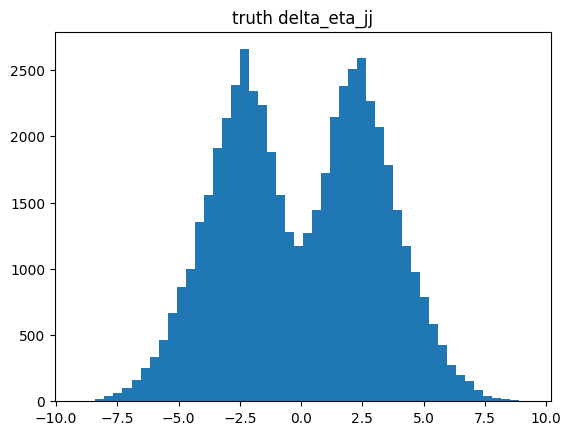

In [19]:
deta_truth = eta_from_features(block(y_val, "j1")) - eta_from_features(block(y_val, "j2"))
plt.hist(deta_truth, bins=50)
plt.title("truth delta_eta_jj")
plt.show()

at_1_bt_0:
  truth-reco correlation: 0.253
  truth-flow correlation: 0.009
at_0_bt_1:
  truth-reco correlation: 0.271
  truth-flow correlation: -0.010
at_1_bt_1:
  truth-reco correlation: 0.253
  truth-flow correlation: 0.004


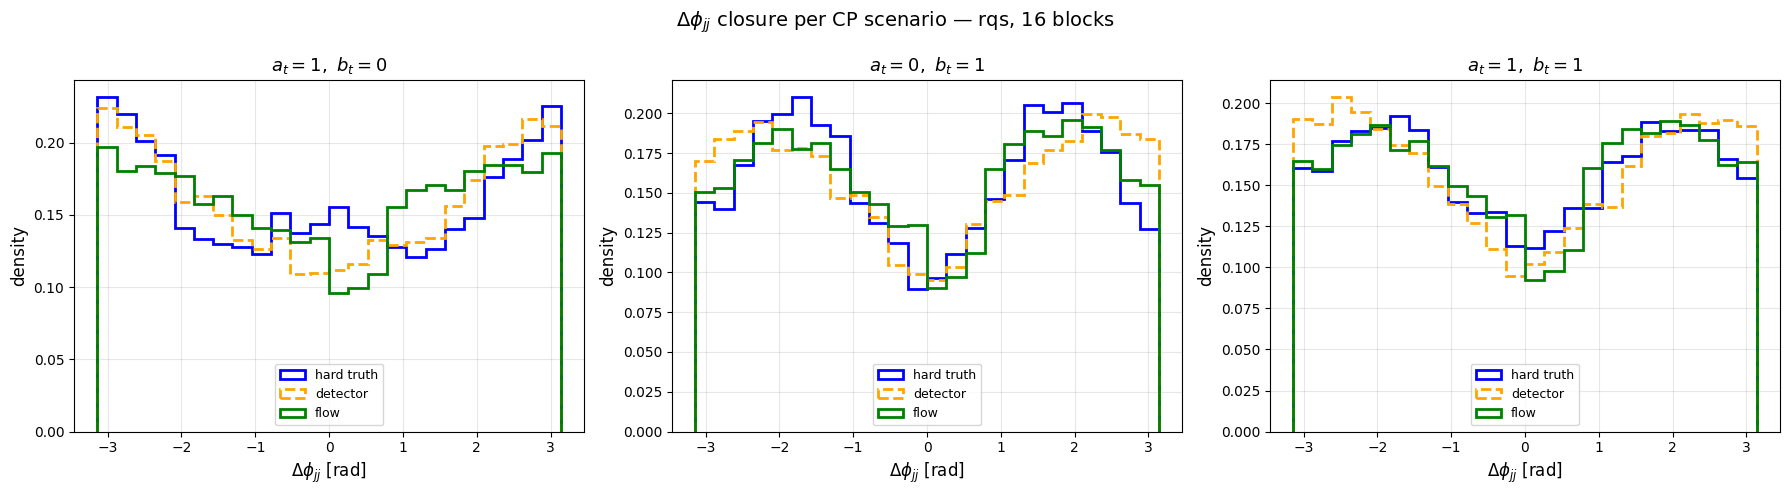

In [20]:
# ── Cell 16: Δφ_jj closure per coupling configuration ────────────────────────

bins    = np.linspace(-np.pi, np.pi, 25)
configs = ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]
labels  = {"at_1_bt_0": r"$a_t=1,\ b_t=0$",
           "at_0_bt_1": r"$a_t=0,\ b_t=1$",
           "at_1_bt_1": r"$a_t=1,\ b_t=1$"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, config in zip(axes, configs):

    mask      = meta_val["sample"].values == config
    flow_mask = np.repeat(mask, N_SAMPLES_PER_EVENT)

    # truth
    truth_dphi = dphi_jj_from_samples(y_val[mask])

    # reco
    reco_dphi = np.array([
        delta_phi(
            phi_from_reco_features(jet_features_from_reco_X(row, 0)),
            phi_from_reco_features(jet_features_from_reco_X(row, 1)),
        )
        for row in X_val[mask]
    ])

    # flow
    flow_dphi = dphi_jj_from_samples(flow_samples_all[flow_mask])

    # plot
    ax.hist(truth_dphi, bins=bins, density=True, histtype="step",
            linewidth=2, color="blue",   label="hard truth")
    ax.hist(reco_dphi,  bins=bins, density=True, histtype="step",
            linewidth=2, color="orange", linestyle="--", label="detector")
    ax.hist(flow_dphi,  bins=bins, density=True, histtype="step",
            linewidth=2, color="green",  label="flow")

    ax.set_xlabel(r"$\Delta\phi_{jj}$ [rad]", fontsize=12)
    ax.set_ylabel("density", fontsize=12)
    ax.set_title(labels[config], fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    corr_truth_reco = np.corrcoef(truth_dphi, reco_dphi)[0, 1]
    corr_truth_flow = np.corrcoef(truth_dphi, flow_dphi[:len(truth_dphi)])[0, 1]
    print(f"{config}:")
    print(f"  truth-reco correlation: {corr_truth_reco:.3f}")
    print(f"  truth-flow correlation: {corr_truth_flow:.3f}")

fig.suptitle(
    r"$\Delta\phi_{jj}$ closure per CP scenario — rqs, 16 blocks",
    fontsize=14,
)
plt.tight_layout()
plt.show()

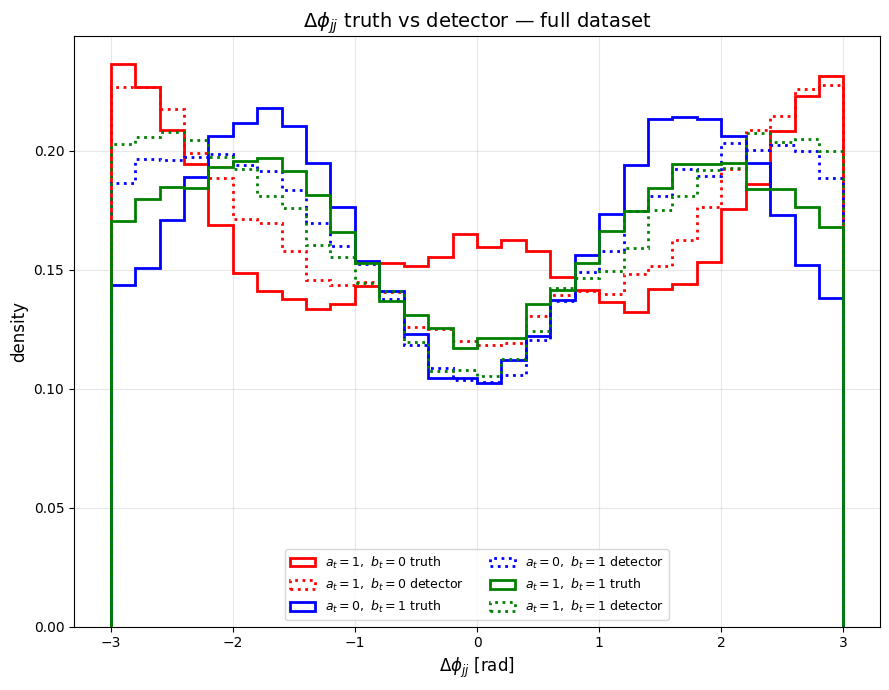

In [21]:
# ── Cell 16: Δφ_jj truth vs detector — full dataset ──────────────────────────

bins    = np.linspace(-3,3,31)
configs = ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]
labels  = {"at_1_bt_0": r"$a_t=1,\ b_t=0$",
           "at_0_bt_1": r"$a_t=0,\ b_t=1$",
           "at_1_bt_1": r"$a_t=1,\ b_t=1$"}
colors  = {"at_1_bt_0": "red", "at_0_bt_1": "blue", "at_1_bt_1": "green"}

plt.figure(figsize=(9, 7))

for config in configs:
    mask = meta["sample"].values == config

    truth_dphi = dphi_jj_from_samples(y[mask])

    reco_dphi = np.array([
        delta_phi(
            phi_from_reco_features(jet_features_from_reco_X(row, 0)),
            phi_from_reco_features(jet_features_from_reco_X(row, 1)),
        )
        for row in X[mask]
    ])

    plt.hist(truth_dphi, bins=bins, density=True, histtype="step",
             linewidth=2, color=colors[config],
             label=f"{labels[config]} truth")
    plt.hist(reco_dphi,  bins=bins, density=True, histtype="step",
             linewidth=2, color=colors[config], linestyle=":",
             label=f"{labels[config]} detector")

plt.xlabel(r"$\Delta\phi_{jj}$ [rad]", fontsize=12)
plt.ylabel("density", fontsize=12)
plt.title(r"$\Delta\phi_{jj}$ truth vs detector — full dataset", fontsize=14)
plt.legend(fontsize=9, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

IndexError: index 12 is out of bounds for axis 1 with size 12

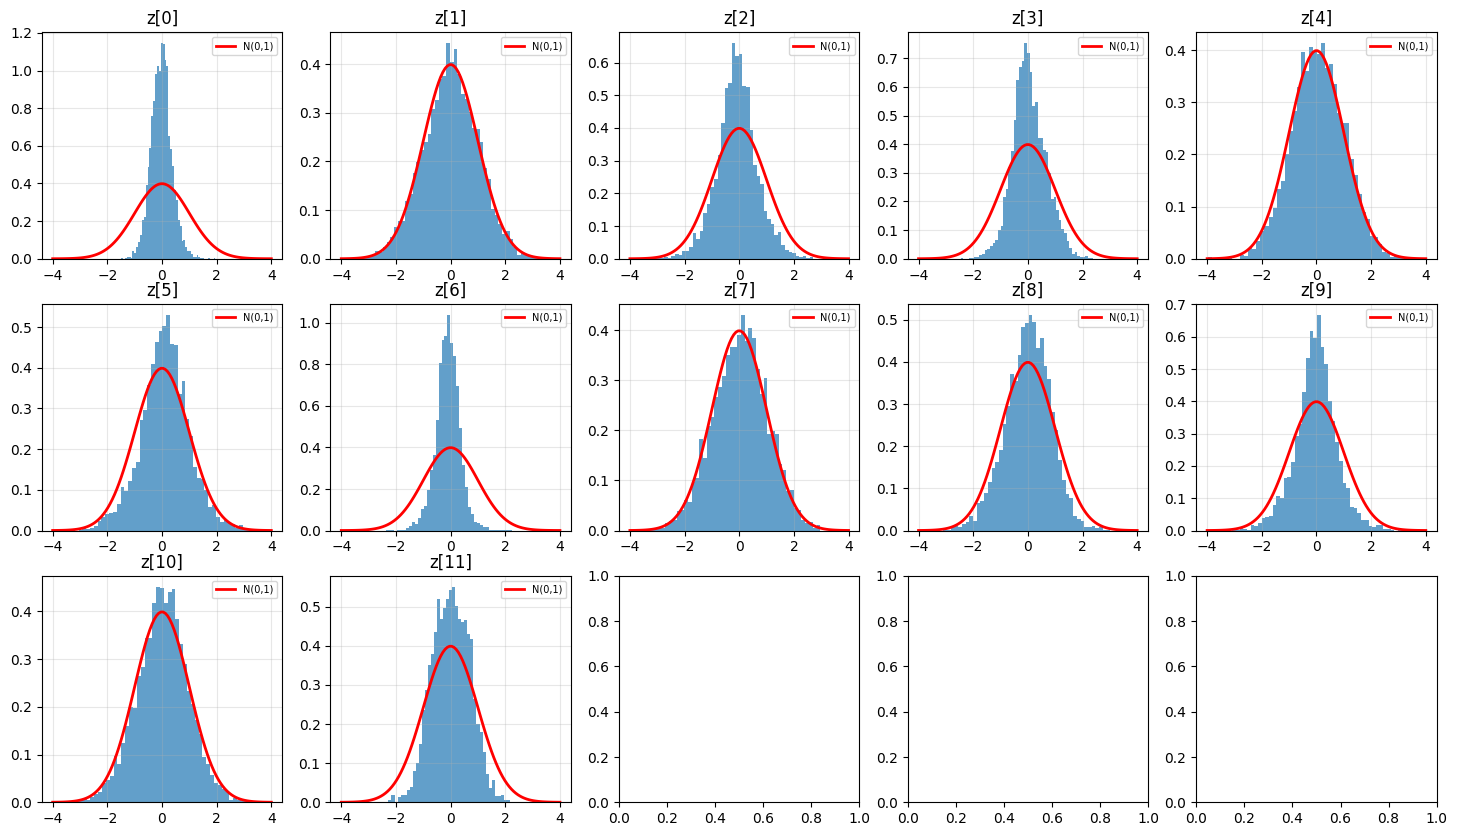

In [22]:
model.eval()
with torch.no_grad():
    z_val, log_det_val = model(
        torch.tensor(y_val_s[:5000], dtype=torch.float32, device=device),
        torch.tensor(X_val_s[:5000], dtype=torch.float32, device=device),
    )
z_val = z_val.cpu().numpy()

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i in range(15):
    axes[i].hist(z_val[:, i], bins=50, density=True, alpha=0.7)
    # overlay standard normal
    x_range = np.linspace(-4, 4, 100)
    axes[i].plot(x_range, 
                 np.exp(-0.5 * x_range**2) / np.sqrt(2 * np.pi), 
                 'r-', linewidth=2, label="N(0,1)")
    axes[i].set_title(f"z[{i}]")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)

plt.suptitle("Latent space z — should match N(0,1) if flow is well trained", fontsize=13)
plt.tight_layout()
plt.show()

# quantitative check
print("z statistics (should be mean≈0, std≈1):")
print(f"  mean: {z_val.mean(axis=0).round(3)}")
print(f"  std:  {z_val.std(axis=0).round(3)}")

Processing at_1_bt_0...
  88,020 events after cuts
Processing at_0_bt_1...
  87,895 events after cuts
Processing at_1_bt_1...
  88,178 events after cuts
Total events: 264,093
Events per sample after cuts: {'at_1_bt_0': np.int64(88020), 'at_0_bt_1': np.int64(87895), 'at_1_bt_1': np.int64(88178)}
Val events matched: 52,819


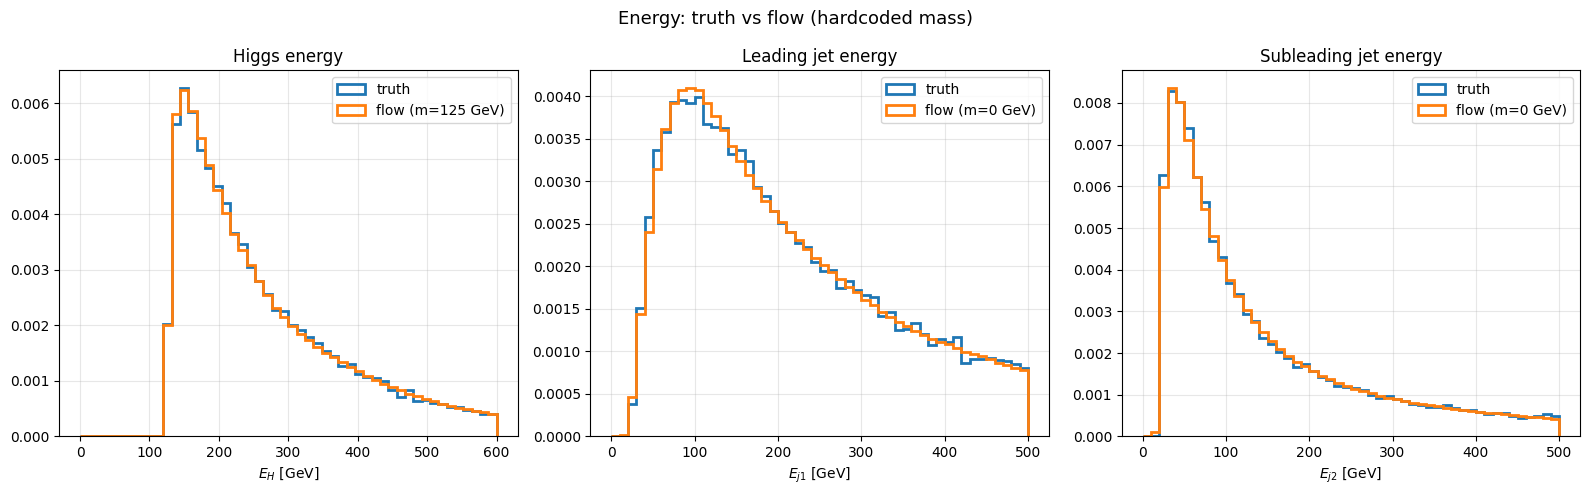

── Higgs ──
  Truth mean: 300.85 GeV  std: 192.52 GeV
  Flow  mean: 300.01 GeV  std: 262.39 GeV
  Δmean: -0.84 GeV

── j1 ──
  Truth mean: 443.81 GeV  std: 509.58 GeV
  Flow  mean: 25242160.00 GeV  std: 58011504640.00 GeV
  Δmean: +25241716.00 GeV

── j2 ──
  Truth mean: 279.99 GeV  std: 389.09 GeV
  Flow  mean: 295.67 GeV  std: 23179.09 GeV
  Δmean: +15.68 GeV



In [41]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# ── Step 1: extract truth energies from ROOT with same cuts ───────────────
branches = [
    "Particle.PID", "Particle.Status",
    "Particle.PT", "Particle.Eta", "Particle.Phi", "Particle.Mass",
    "Particle.E",
    "Jet.PT", "Jet.Eta", "Jet.Phi", "Jet.Mass",
    "Photon.PT", "Photon.Eta", "Photon.Phi", "Photon.E",
]

E_truth_all = {"H": [], "j1": [], "j2": []}

for sample_name, path in input_files.items():
    print(f"Processing {sample_name}...")
    with uproot.open(path) as f:
        arr = f[TREE_NAME].arrays(branches, library="ak")

    pid    = arr["Particle.PID"]
    status = arr["Particle.Status"]

    is_higgs       = (pid == 25) & (status == 22)
    is_hard_parton = (status == 23) & ((pid == 21) | (abs(pid) <= 5))

    h_E  = arr["Particle.E"][is_higgs]
    h_pt = arr["Particle.PT"][is_higgs]
    p_E  = arr["Particle.E"][is_hard_parton]
    p_pt = arr["Particle.PT"][is_hard_parton]

    n_higgs   = ak.num(h_pt)
    n_partons = ak.num(p_pt)
    n_jets    = ak.num(arr["Jet.PT"])
    n_photons = ak.num(arr["Photon.PT"])

    mask = (n_higgs == 1) & (n_partons == 2) & (n_photons >= 2) & (n_jets >= 2)

    pho_pt  = arr["Photon.PT"][mask]
    pho_eta = arr["Photon.Eta"][mask]
    pho_phi = arr["Photon.Phi"][mask]
    pho_e   = arr["Photon.E"][mask]

    _, _, _, hrec_m = photons_to_higgs(
        ak.to_numpy(pho_pt[:, 0]),  ak.to_numpy(pho_eta[:, 0]),
        ak.to_numpy(pho_phi[:, 0]), ak.to_numpy(pho_e[:, 0]),
        ak.to_numpy(pho_pt[:, 1]),  ak.to_numpy(pho_eta[:, 1]),
        ak.to_numpy(pho_phi[:, 1]), ak.to_numpy(pho_e[:, 1]),
    )
    mass_mask_np = np.abs(hrec_m - 125.0) < MASS_WINDOW

    h_E_np  = ak.to_numpy(h_E[mask][:, 0])[mass_mask_np]
    p_E_np  = ak.to_numpy(p_E[mask])[mass_mask_np]
    p_pt_np = ak.to_numpy(p_pt[mask])[mass_mask_np]

    # pT ordering
    swap = p_pt_np[:, 0] < p_pt_np[:, 1]
    for a in [p_E_np, p_pt_np]:
        tmp = a[swap, 0].copy()
        a[swap, 0] = a[swap, 1]
        a[swap, 1] = tmp

    E_truth_all["H"].append(h_E_np)
    E_truth_all["j1"].append(p_E_np[:, 0])
    E_truth_all["j2"].append(p_E_np[:, 1])

    print(f"  {len(h_E_np):,} events after cuts")

E_H_truth_full  = np.concatenate(E_truth_all["H"])
E_j1_truth_full = np.concatenate(E_truth_all["j1"])
E_j2_truth_full = np.concatenate(E_truth_all["j2"])

print(f"Total events: {len(E_H_truth_full):,}")

# ── Step 2: match to validation set ──────────────────────────────────────
# truth full has 264k events in order: all at_1_bt_0, then at_0_bt_1, then at_1_bt_1
# meta_val tells us which sample each val event came from
# we need to recover the position of each val event in the full dataset

# rebuild the full index using meta_full
n_per_sample = {
    "at_1_bt_0": (meta_full["sample"] == "at_1_bt_0").sum(),
    "at_0_bt_1": (meta_full["sample"] == "at_0_bt_1").sum(),
    "at_1_bt_1": (meta_full["sample"] == "at_1_bt_1").sum(),
}
print(f"Events per sample after cuts: {n_per_sample}")

# get val indices in the full (unshuffled) dataset
# meta_full was shuffled in cell 5, meta_val is a subset of that
# the index of meta_val in meta_full gives us the position in the full array
val_indices = meta_val.index.values  # indices into X_full/y_full after shuffle

E_H_val  = E_H_truth_full[val_indices]
E_j1_val = E_j1_truth_full[val_indices]
E_j2_val = E_j2_truth_full[val_indices]

print(f"Val events matched: {len(E_H_val):,}")

# ── Step 3: derive energy from flow samples with hardcoded masses ─────────
H_pt  = pt_from_features(block(flow_samples_all, "H"))
H_eta = eta_from_features(block(flow_samples_all, "H"))

j1_pt  = pt_from_features(block(flow_samples_all, "j1"))
j1_eta = eta_from_features(block(flow_samples_all, "j1"))

j2_pt  = pt_from_features(block(flow_samples_all, "j2"))
j2_eta = eta_from_features(block(flow_samples_all, "j2"))

E_H_derived  = np.sqrt(H_pt**2  * np.cosh(H_eta)**2  + 125.0**2)
E_j1_derived = np.sqrt(j1_pt**2 * np.cosh(j1_eta)**2 + 0.0)
E_j2_derived = np.sqrt(j2_pt**2 * np.cosh(j2_eta)**2 + 0.0)

# repeat truth to match flow samples (N_SAMPLES_PER_EVENT samples per event)
E_H_val_rep  = np.repeat(E_H_val,  N_SAMPLES_PER_EVENT)
E_j1_val_rep = np.repeat(E_j1_val, N_SAMPLES_PER_EVENT)
E_j2_val_rep = np.repeat(E_j2_val, N_SAMPLES_PER_EVENT)

# ── Step 4: plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bins_H = np.linspace(0, 600, 51)
bins_j = np.linspace(0, 500, 51)

axes[0].hist(E_H_val_rep,  bins=bins_H, density=True, histtype="step", linewidth=2, label="truth")
axes[0].hist(E_H_derived,  bins=bins_H, density=True, histtype="step", linewidth=2, label="flow (m=125 GeV)")
axes[0].set_xlabel(r"$E_H$ [GeV]")
axes[0].set_title("Higgs energy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(E_j1_val_rep, bins=bins_j, density=True, histtype="step", linewidth=2, label="truth")
axes[1].hist(E_j1_derived, bins=bins_j, density=True, histtype="step", linewidth=2, label="flow (m=0 GeV)")
axes[1].set_xlabel(r"$E_{j1}$ [GeV]")
axes[1].set_title("Leading jet energy")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(E_j2_val_rep, bins=bins_j, density=True, histtype="step", linewidth=2, label="truth")
axes[2].hist(E_j2_derived, bins=bins_j, density=True, histtype="step", linewidth=2, label="flow (m=0 GeV)")
axes[2].set_xlabel(r"$E_{j2}$ [GeV]")
axes[2].set_title("Subleading jet energy")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Energy: truth vs flow (hardcoded mass)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 5: quantitative ──────────────────────────────────────────────────
for name, E_truth, E_flow in [
    ("Higgs", E_H_val_rep,  E_H_derived),
    ("j1",    E_j1_val_rep, E_j1_derived),
    ("j2",    E_j2_val_rep, E_j2_derived),
]:
    print(f"── {name} ──")
    print(f"  Truth mean: {np.nanmean(E_truth):.2f} GeV  std: {np.nanstd(E_truth):.2f} GeV")
    print(f"  Flow  mean: {np.nanmean(E_flow):.2f} GeV  std: {np.nanstd(E_flow):.2f} GeV")
    print(f"  Δmean: {np.nanmean(E_flow) - np.nanmean(E_truth):+.2f} GeV")
    print()

In [45]:
# check if matching is correct
# Higgs energy should be > 125 GeV always (mass is 125 GeV)
print(f"Min truth H energy: {E_H_val_rep.min():.2f} GeV")
print(f"Min flow  H energy: {E_H_derived.min():.2f} GeV")

# check sample distribution matches
print(f"\nmeta_val sample counts:")
print(meta_val["sample"].value_counts())

print(f"\nE_H_val mean per sample:")
for sample in ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]:
    mask = meta_val["sample"].values == sample
    print(f"  {sample}: {E_H_val[mask].mean():.2f} GeV")

Min truth H energy: 125.02 GeV
Min flow  H energy: 125.00 GeV

meta_val sample counts:
sample
at_1_bt_0    17690
at_1_bt_1    17605
at_0_bt_1    17524
Name: count, dtype: int64

E_H_val mean per sample:
  at_1_bt_0: 300.79 GeV
  at_0_bt_1: 300.39 GeV
  at_1_bt_1: 301.37 GeV
